In [24]:
SUBJECT_IDS = list(range(1, 11)) # first ten
# SUBJECT_IDS = list(range(1, 110)) # full

# # executed
# RUNS_FOR_TRAINING = [3, 7]
# RUNS_FOR_TESTING = [11]
# motor imagery
RUNS_FOR_TRAINING = [4, 8]
RUNS_FOR_TESTING = [12]
# # executed -> motor imagery
# RUNS_FOR_TRAINING = [3, 7]
# RUNS_FOR_TESTING = [12]

In [25]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import mne
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

In [26]:
# 1. Data Loading and Preprocessing Function
def load_and_epoch(subject_id: int, runs: list, tmin=0.5, tmax=3.5, l_freq=8.0, h_freq=30.0):
    """
    Loads specified runs for a subject, applies bandpass filter, and extracts 3-second epochs.
    """
    file_paths = mne.datasets.eegbci.load_data(subject=subject_id, runs=runs, update_path=False)
    # might need "subjects=" instead of "subject=" if using different version of MNE
    # file_paths = mne.datasets.eegbci.load_data(subjects=subject_id, runs=runs, update_path=False)
    
    # Load each EDF and standardize channel names on ALL of them
    raws = []
    for f in file_paths:
        r = mne.io.read_raw_edf(f, preload=True)
        mne.datasets.eegbci.standardize(r)  # Strips trailing dots and cleans names
        raws.append(r)
    
    montage = mne.channels.make_standard_montage('standard_1005')
    
    raw = mne.concatenate_raws(raws)
    raw.set_montage(montage, match_case=False)
    
    # Universal preprocessing: 8-30 Hz Sensorimotor Band
    raw.filter(l_freq, h_freq, fir_design='firwin', skip_by_annotation='edge')
    
    # Extract events: T1 (Left Fist), T2 (Right Fist)
    events, event_dict = mne.events_from_annotations(raw, event_id={'T1': 1, 'T2': 2})
    
    # Epoching: 0.5s to 3.5s after the visual cue
    epochs = mne.Epochs(
        raw, 
        events, 
        event_id=event_dict, 
        tmin=tmin, 
        tmax=tmax, 
        baseline=None, 
        preload=True
    )
    
    X = epochs.get_data(copy=False)  # Shape: (trials, channels, timepoints)
    y = epochs.events[:, -1] - 1     # Map T1->0 (Left), T2->1 (Right)
    
    return epochs, X, y

In [27]:
# silence the mne logs if you want to avoid huge logs from next cell
mne.set_log_level('WARNING')

In [28]:
records = []
fitted_pipelines = {}
cached_train_infos = {}

print("=== Starting Intra-Subject Batch Benchmark: CSP vs RG ===")
for sub in SUBJECT_IDS:
    try:
        # 1. Load subject data
        train_epochs, X_train, y_train = load_and_epoch(sub, RUNS_FOR_TRAINING)
        test_epochs, X_test, y_test = load_and_epoch(sub, RUNS_FOR_TESTING)
        
        # 2. Pipeline 1: CSP + LDA
        pipe_csp = Pipeline([
            ("CSP", CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)),
            ("LDA", LinearDiscriminantAnalysis())
        ])
        pipe_csp.fit(X_train, y_train)
        probs_csp = pipe_csp.predict_proba(X_test) # Extract probabilities
        
        # 3. Pipeline 2: Riemannian Geometry + Logistic Regression
        pipe_rg = Pipeline([
            ("Covariances", Covariances(estimator='lwf')),
            ("TangentSpace", TangentSpace(metric='riemann')),
            ("LR", LogisticRegression(solver="lbfgs", max_iter=1000))
        ])
        pipe_rg.fit(X_train, y_train)
        probs_rg = pipe_rg.predict_proba(X_test) # Extract probabilities
        
        # --- SCORE FUSION ---
        # Average the probabilities (soft voting)
        fused_probs = (probs_csp + probs_rg) / 2.0
        
        # Get final predictions and compute accuracy
        fused_preds = np.argmax(fused_probs, axis=1)
        acc_fused = np.mean(fused_preds == y_test)
        
        # 4. Store metrics
        records.append({
            "Subject": f"S{sub:02d}",
            "Subject_ID": sub,
            "CSP_Accuracy": pipe_csp.score(X_test, y_test), # Optional: keep individual scores
            "RG_Accuracy": pipe_rg.score(X_test, y_test),   # Optional: keep individual scores
            "Fused_Accuracy": acc_fused,
            "Train_Trials": len(y_train),
            "Test_Trials": len(y_test)
        })
    except Exception as e:
        print(f"Subject {sub:02d} failed: {e}")

if not records:
    raise RuntimeError("No subjects were successfully evaluated. Check run numbers or data paths.")

df_intra = pd.DataFrame(records)

=== Starting Intra-Subject Batch Benchmark: CSP vs RG ===



Cohort Size: 10 subjects evaluated
CSP+LDA Mean:    59.33% ± 5.48% SEM | p(1-tailed) = 6.1488e-02
RG+LR Mean:      59.33% ± 6.24% SEM | p(1-tailed) = 8.4533e-02
Fused Mean:      58.00% ± 5.36% SEM | p(1-tailed) = 8.4751e-02
-----------------------------------------------------------------
Paired Diff (RG - CSP):      0.00% | p = 1.0000e+00
Paired Diff (Fused - RG):    -1.33% | p = 6.4242e-01


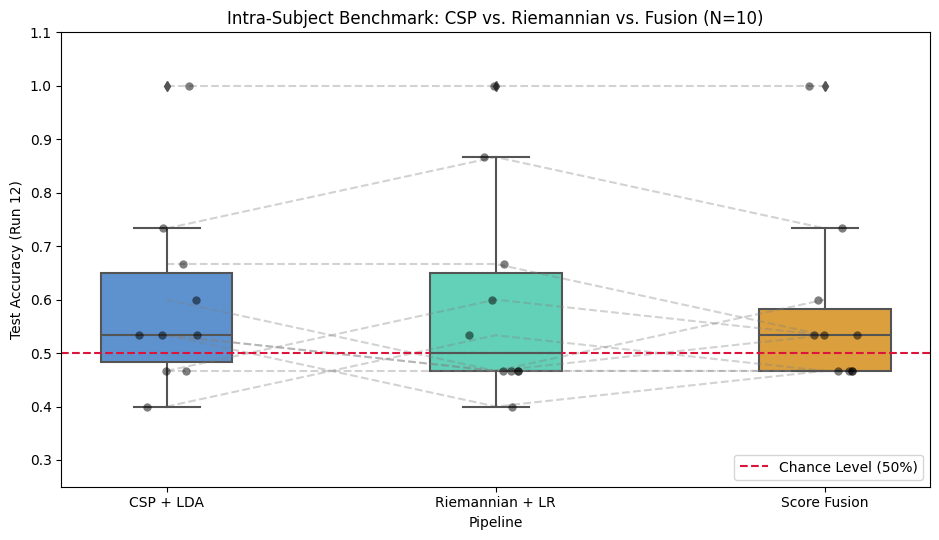

In [29]:
# Inferential Statistics: CSP vs RG vs Fused Intra-Subject
n = len(df_intra)

mean_csp = df_intra['CSP_Accuracy'].mean()
sem_csp = df_intra['CSP_Accuracy'].std(ddof=1) / np.sqrt(n)

mean_rg = df_intra['RG_Accuracy'].mean()
sem_rg = df_intra['RG_Accuracy'].std(ddof=1) / np.sqrt(n)

# 1. Add Fused statistics
mean_fused = df_intra['Fused_Accuracy'].mean()
sem_fused = df_intra['Fused_Accuracy'].std(ddof=1) / np.sqrt(n)

# Single-sample tests vs 50% chance
t_csp, p_csp_two = stats.ttest_1samp(df_intra['CSP_Accuracy'], popmean=0.50)
p_csp_one = p_csp_two / 2 if t_csp > 0 else 1.0 - (p_csp_two / 2)

t_rg, p_rg_two = stats.ttest_1samp(df_intra['RG_Accuracy'], popmean=0.50)
p_rg_one = p_rg_two / 2 if t_rg > 0 else 1.0 - (p_rg_two / 2)

t_fused, p_fused_two = stats.ttest_1samp(df_intra['Fused_Accuracy'], popmean=0.50)
p_fused_one = p_fused_two / 2 if t_fused > 0 else 1.0 - (p_fused_two / 2)

# Paired tests comparing models
t_paired_rg_csp, p_paired_rg_csp = stats.ttest_rel(df_intra['RG_Accuracy'], df_intra['CSP_Accuracy'])
t_paired_fused_rg, p_paired_fused_rg = stats.ttest_rel(df_intra['Fused_Accuracy'], df_intra['RG_Accuracy'])

# 2. Print Summary with Fused model included
print("\n" + "=" * 65)
print(f"Cohort Size: {n} subjects evaluated")
print(f"CSP+LDA Mean:    {mean_csp:.2%} ± {sem_csp:.2%} SEM | p(1-tailed) = {p_csp_one:.4e}")
print(f"RG+LR Mean:      {mean_rg:.2%} ± {sem_rg:.2%} SEM | p(1-tailed) = {p_rg_one:.4e}")
print(f"Fused Mean:      {mean_fused:.2%} ± {sem_fused:.2%} SEM | p(1-tailed) = {p_fused_one:.4e}")
print("-" * 65)
print(f"Paired Diff (RG - CSP):      {(mean_rg - mean_csp):.2%} | p = {p_paired_rg_csp:.4e}")
print(f"Paired Diff (Fused - RG):    {(mean_fused - mean_rg):.2%} | p = {p_paired_fused_rg:.4e}")
print("=" * 65)

# 3. Reshape dataframe including Fused_Accuracy
df_melt = df_intra.melt(
    id_vars=["Subject"], 
    value_vars=["CSP_Accuracy", "RG_Accuracy", "Fused_Accuracy"], 
    var_name="Pipeline", 
    value_name="Accuracy" if "value_name" in df_intra else "Accuracy"
)
df_melt["Pipeline"] = df_melt["Pipeline"].replace({
    "CSP_Accuracy": "CSP + LDA", 
    "RG_Accuracy": "Riemannian + LR",
    "Fused_Accuracy": "Score Fusion"
})

# 4. Plot 3 models side-by-side
plt.figure(figsize=(9.5, 5.5))
sns.boxplot(x="Pipeline", y="Accuracy", data=df_melt, palette=["#4A90E2", "#50E3C2", "#F5A623"], width=0.4)
sns.stripplot(x="Pipeline", y="Accuracy", data=df_melt, color="black", alpha=0.5, jitter=0.1, size=6)

# Connect individual subjects across all 3 conditions
for sub in df_intra["Subject"].unique():
    sub_data = df_intra[df_intra["Subject"] == sub]
    plt.plot(
        [0, 1, 2], 
        [sub_data["CSP_Accuracy"].values[0], sub_data["RG_Accuracy"].values[0], sub_data["Fused_Accuracy"].values[0]], 
        color="gray", linestyle="--", alpha=0.35, zorder=1
    )

plt.axhline(0.50, color="crimson", linestyle="--", linewidth=1.5, label="Chance Level (50%)")
plt.ylim(0.25, 1.1)
plt.ylabel(f"Test Accuracy (Run {RUNS_FOR_TESTING[0]})")
plt.title(f"Intra-Subject Benchmark: CSP vs. Riemannian vs. Fusion (N={n})")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()